# Notebook de Modelo Preditivo (ML)

Modelo Preditivo para Antecipação de NPS

Estratégia Adotada:

Optei pelo modelo de Classificação utilizando o algoritmo Random Forest.
Justificativa: O objetivo é categorizar clientes em potenciais "Detratores" para permitir uma ação imediata do time de retenção. O Random Forest lida bem com as relações não-lineares entre atrasos e reclamações identificadas na EDA.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_nps = pd.read_csv('data/desafio_nps_fase_1.csv')

In [ ]:
# Realizei um get_dummies, para transformar a coluna região em booleana, para facilitar na correlação
df_nps_ajustado = pd.get_dummies(df_nps, columns=['customer_region'], drop_first=True)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

    Detrator       0.85      0.98      0.91       555
      Neutro       0.71      0.24      0.36       135
    Promotor       0.94      1.00      0.97        60

    accuracy                           0.85       750
   macro avg       0.83      0.74      0.74       750
weighted avg       0.83      0.85      0.81       750



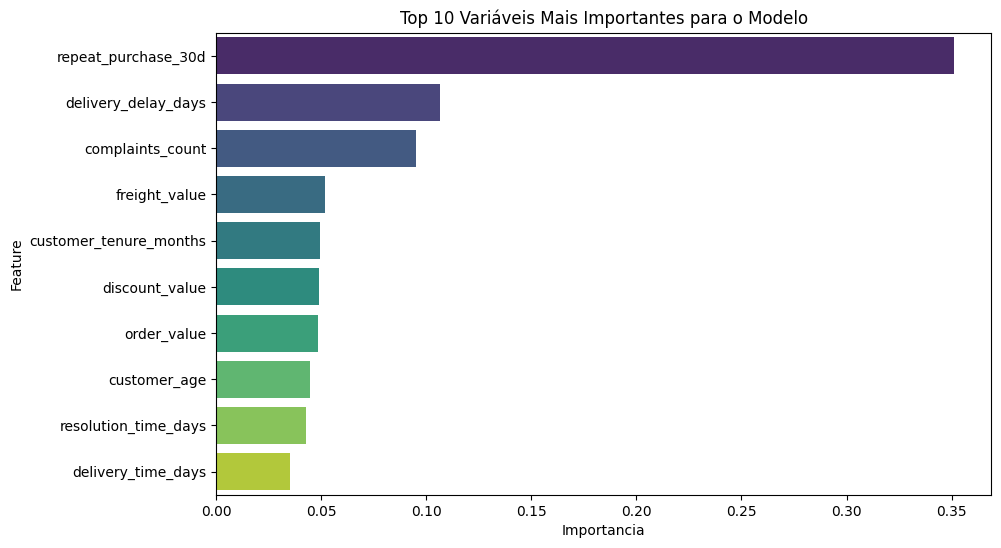

In [12]:
# Criando uma função para auxiliar na criação da coluna que será utilizada como target
def categoriza_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

# Categorização: Transformando notas em classes (Detrator, Neutro, Promotor)
df_nps_ajustado['nps_class'] = df_nps_ajustado['nps_score'].apply(categoriza_nps)

# Preparação e Seleção de Variáveis
# Foram removidos IDs e variáveis de "vazamento" como csat_internal_score e nps_score original.
# mantive apenas dados operacionais disponíveis antes da entrega final para garantir a capacidade preditiva do modelo.
colunas_para_remover = ['customer_id', 'order_id', 'nps_score', 'csat_internal_score', 'nps_class']
X = df_nps_ajustado.drop(columns=colunas_para_remover)
y = df_nps_ajustado['nps_class']

## Train/Test Split: Separando 30% para teste com estratificação para manter o equilíbrio das classes
# O parâmetro 'stratify=y' garante que a proporção de detratores/promotores seja mantida nas duas bases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Treinamento: Usando pesos balanceados para compensar a menor quantidade de Promotores
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=9, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# Avaliação: Foco no Recall de Detratores para minimizar falhas na identificação de clientes insatisfeitose
y_pred = modelo_rf.predict(X_test)
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# Visualizando as variáveis mais importantes para o modelo
importancias = modelo_rf.feature_importances_
features = X.columns
df_importancias = pd.DataFrame({'Feature': features, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias.head(10), x='Importancia', y='Feature', palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes para o Modelo')
plt.show()

Conclusões e Próximos Passos
O modelo demonstrou alta capacidade de identificar Detratores (Recall de 0.98).
Recomendação: Integrar este modelo ao fluxo logístico. Pedidos com "Score de Detração" alto devem disparar alertas automáticos para o SAC e cupons de desconto preventivos

In [13]:
import joblib

# Salvando o modelo treinado
joblib.dump(modelo_rf, 'models/random_forest_nps_model.pkl')

# Salvando as colunas de treinamento para garantir que a entrada seja sempre a mesma
model_columns = list(X.columns)
joblib.dump(model_columns, 'models/model_columns.pkl')

['model_columns.pkl']